# CPLE

## Binarna Klasyfikacja

Zbiór danych MNIST:

$X_a$ – macierz cech (każdy obrazek 8×8 spłaszczony do 64 liczb).

$Y_a$ – prawdziwe etykiety cyfr od 0 do 9.

In [1]:
from sklearn.datasets import load_digits
import numpy as np
from sklearn.linear_model import LogisticRegression
from scipy.optimize import fmin_bfgs

In [2]:
X_a, Y_a = load_digits(return_X_y=True)

# Filtrowanie danych, aby stworzyć problem binarny: tylko cyfry 0 i 1
X = np.vstack((X_a[Y_a == 0], X_a[Y_a == 1]))
Y = np.vstack((np.expand_dims(Y_a, axis=1)[Y_a==0], np.expand_dims(Y_a, axis=1)[Y_a==1]))

# Całkowita liczba próbek (360)
nb_samples = X.shape[0]
nb_dimensions = X.shape[1]
nb_unlabeled = 150

# przechowanie prawdziwych etykiet
Y_true = np.zeros((nb_unlabeled,))

## Losowy wybór 150 indeksów próbek, które będą traktowane jako nieoznaczone
unlabeled_id = np.random.choice(np.arange(0, nb_samples, 1), 
replace=False, size=nb_unlabeled)

Y_true = Y[unlabeled_id].copy()
Y[unlabeled_id] = -1

### Trenowanie modelu bazowego (regresja logistyczna)
1. Model uczy się tylko na tych próbkach, które mają prawdziwe etykiety 
                                

In [5]:
# # Inicjalizacja klasyfikatora bazowego - regresja logistyczna
lr_test = LogisticRegression(
    solver="liblinear",
    max_iter=1000,        
    random_state=1000      
)

# Uczymy model TYLKO na danych oznaczonych
lr_test.fit(X[Y.squeeze() != -1], Y[Y.squeeze() != -1].squeeze())

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,1000
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


### Testowanie modelu na danych nieoznaczonych

Sprawdzenie dokładności tego modelu na 150 próbkach nieoznaczonych

In [6]:
unlabeled_score = lr_test.score(X[Y.squeeze() == -1], Y_true)
print(unlabeled_score)

0.49333333333333335


Walidacja krzyżowa na całym zbiorze

In [8]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

total_cv_scores = cross_val_score(
    LogisticRegression(solver="liblinear", max_iter=1000, random_state=1000),
    X, 
    Y.squeeze(), 
    cv=10, 
    n_jobs=-1
)
print(total_cv_scores)
print(total_cv_scores.mean())

[0.41666667 0.58333333 0.36111111 0.47222222 0.41666667 0.5
 0.38888889 0.36111111 0.52777778 0.41666667]
0.4444444444444445


### Inicjalizacja modelu i miękkich etykiet
Ten model posłuży w pętli optymalizacyjnej (min–max), gdzie będziemy naprzemiennie:

-> aktualizować parametry modelu 
𝜃

-> aktualizować miękkie etykiety 
𝑄
.

In [10]:
lr = LogisticRegression(
    solver="liblinear",
    max_iter=1000,
    random_state=1000
)

Losowa inicjalizacja miękkich etykiet

In [11]:
q0 = np.random.uniform(0, 1, size=nb_unlabeled)

W pewnych etapach (np. do trenowania regresji logistycznej) potrzebujemy „twardych” etykiet (0 lub 1).
Dlatego definiujemy prostą funkcję progową

$$
y(q_i) =
\begin{cases}
0 & \text{jeśli } q_i < 0.5,\\[4pt]
1 & \text{w przeciwnym razie.}
\end{cases}
$$


In [12]:
trh = np.vectorize(lambda x: 0.0 if x < 0.5 else 1.0)
Y_soft = trh(q0)

### Ważony logarytmiczny błąd

$$
L(\overline{y}, \overline{p}, \overline{w}) = \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]
$$

In [13]:
def weighted_log_loss(yt, p, w=None, eps=1e-15):
    if w is None:
        w_t = np.ones((yt.shape[0], 2))
    else:
        w_t = np.vstack((w, 1.0 - w)).T
    Y_t = np.vstack((1.0 - yt.squeeze(), yt.squeeze())).T
    L_t = np.sum(w_t * Y_t * np.log(np.clip(p, eps, 1.0 - eps)), axis=1)
    
    return np.mean(L_t)

### Budowa zbioru z miękkimi etykietami

Tworzy nowy zbiór danych $X_n$, $Y_n$, który:

- zawiera wszystkie próbki (oznaczone + nieoznaczone),

- dla nieoznaczonych wstawia etykiety wynikające z miękkich wartości q

In [14]:
def build_dataset(q):
    Y_unlabeled = trh(q)
    X_n = np.zeros((nb_samples, nb_dimensions))
    X_n[0:nb_samples - nb_unlabeled] = X[Y.squeeze()!=-1]
    X_n[nb_samples - nb_unlabeled:] = X[Y.squeeze()==-1]

    Y_n = np.zeros((nb_samples, 1))
    Y_n[0:nb_samples - nb_unlabeled] = Y[Y.squeeze()!=-1]
    Y_n[nb_samples - nb_unlabeled:] = np.expand_dims(Y_unlabeled, axis=1)
    
    return X_n, Y_n

### Kontrastywny logarytm wiarygodności

$$ 
CL = L_{\text{semi}} - L_{\text{sup}}
$$

jeśli różnica jest dodatnia, oznacza to, że uwzględnienie danych nieoznaczonych poprawia dopasowanie modelu.

In [15]:
def log_likelihood(q):
    X_n, Y_n = build_dataset(q)
    Y_soft = trh(q)
    lr.fit(X_n, Y_n.squeeze())
    p_sup = lr.predict_proba(X[Y.squeeze() != -1])
    p_semi = lr.predict_proba(X[Y.squeeze() == -1])
    l_sup = weighted_log_loss(Y[Y.squeeze() != -1], p_sup)
    l_semi = weighted_log_loss(Y_soft, p_semi, q)
    return l_semi - l_sup

### Optymalizacja miękkich etykiet (q)
Minimalizujemy funkcję log_likelihood(q) względem wektora q:
$$Q^* = \arg_Q \min CL(\theta, \theta^{\text{sup}}, X_t, Q)$$
Po zakończeniu optymalizacji, q_end zawiera najlepsze (pesymistyczne) miękkie etykiety.

In [16]:
from scipy.optimize import minimize

In [17]:
result = minimize(fun=log_likelihood, 
                  x0=q0, 
                  method='Powell', 
                  options={'disp': True, 'maxiter': 50})

q_end = result.x

Optimization terminated successfully.
         Current function value: -0.233495
         Iterations: 6
         Function evaluations: 35403


### Budowa finalnego zbioru danych i ponowne uczenie

In [15]:
X_n, Y_n = build_dataset(q_end)

In [ ]:
final_semi_cv_scores = cross_val_score(
    LogisticRegression(solver="liblinear", max_iter=10000, random_state=1000),
    X_n, Y_n.squeeze(), cv=10, n_jobs=-1
)
print(final_semi_cv_scores)


[0.97222222 0.97222222 1.         1.         0.97222222 0.83333333
 0.5        0.72222222 0.47222222 0.44444444]


In [17]:
print(final_semi_cv_scores.mean())

0.788888888888889


# Zadanko :)

Uzupełnij kod, aby zaimplementować i ocenić algorytm CPLE dla zbioru danych "Two Moons", gdzie tylko niewielka część danych jest oznaczona.

## Instruckcja 

#TODO 1: Ustaw zmienną n_labeled na wybraną przez siebie (małą) liczbę próbek oznaczonych

#TODO 2: W funkcji objective_for_q, użyj metody .fit() obiektu lr_cple, aby wytrenować model na danych X_n i Y_n.

#TODO 3: W objective_for_q, użyj metody .predict_proba() wytrenowanego modelu lr_cple, aby uzyskać przewidywane prawdopodobieństwa dla danych oznaczonych X_labeled i zapisz je w p_sup.

#TODO 4: W tym samym miejscu, wywołaj funkcję weighted_log_loss, aby obliczyć stratę dla części nadzorowanej. Jako argumenty podaj prawdziwe etykiety Y_labeled i przewidziane prawdopodobieństwa p_sup.

#TODO 5: Ustaw zmienną max_iterations_bfgs na rozsądną wartość, np. 100.

#TODO 6: Po optymalizacji q, użyj metody .fit() obiektu lr_cple, aby wytrenować ostateczny model na danych X_final i Y_final.

#TODO 7: Po wytrenowaniu ostatecznego modelu, użyj jego metody .predict() na danych X_unlabeled, aby uzyskać finalne przewidywania. Następnie użyj funkcji accuracy_score z sklearn.metrics, aby porównać te przewidywania z prawdziwymi etykietami Y_unlabeled_true i zapisać wynik w cple_score.

Przygotowanie danych

In [19]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
n_total = 300
n_labeled = TODO 1
n_unlabeled = n_total - n_labeled

In [21]:
X, Y = make_moons(n_samples=n_total, noise=0.15, random_state=1000)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_labeled, X_unlabeled, Y_labeled, Y_unlabeled_true = train_test_split(
    X, Y, train_size=n_labeled, random_state=1000, stratify=Y)

X_combined = np.vstack((X_labeled, X_unlabeled))
Y_combined = np.hstack((Y_labeled, np.full(n_unlabeled, -1, dtype=int)))

Implementacja CPLE

In [22]:
# Model bazowy (dla porównania)
lr_base = LogisticRegression(solver="liblinear", random_state=1000)
lr_base.fit(X_labeled, Y_labeled)
base_score = accuracy_score(Y_unlabeled_true, lr_base.predict(X_unlabeled))

In [23]:
lr_cple = LogisticRegression(solver="liblinear", random_state=1000)
q0 = np.random.uniform(0, 1, size=n_unlabeled)
trh = np.vectorize(lambda x: 0.0 if x < 0.5 else 1.0)

In [24]:
def weighted_log_loss(yt, p, w=None, eps=1e-15):
    if w is None:
        w_t = np.ones((yt.shape[0], 2))
    else:
        w_t = np.vstack((1.0 - w, w)).T

    Y_t = np.vstack((1.0 - yt.squeeze(), yt.squeeze())).T
    p_clipped = np.clip(p, eps, 1.0 - eps)
    L_t = -np.sum(w_t * Y_t * np.log(p_clipped), axis=1)
    return np.mean(L_t)

In [25]:
def build_dataset(q):
    Y_unlabeled_hard = trh(q)
    X_n = np.vstack((X_labeled, X_unlabeled))
    Y_n = np.hstack((Y_labeled, Y_unlabeled_hard))
    return X_n, Y_n

In [ ]:
def objective_for_q(q):
    X_n, Y_n = build_dataset(q)
    Y_unlabeled_hard_current = trh(q) 

    # Wytrenuj model lr_cple na danych X_n, Y_n
    lr_cple.fit( TODO 2) # 

    #Oblicz prawdopodobieństwa dla danych oznaczonych 
    p_sup = lr_cple.predict_proba( TODO 3 ) 
        
    # Oblicz prawdopodobieństwa dla danych nieoznaczonych 
    p_semi = lr_cple.predict_proba( TODO 3)

    # Oblicz stratę dla części nadzorowanej (l_sup) używając weighted_log_loss
    l_sup = weighted_log_loss(Y_labeled,  TODO 4 ) 
    # Oblicz stratę dla części półnadzorowanej (l_semi) używając weighted_log_loss

    l_semi = weighted_log_loss(Y_unlabeled_hard_current,  TODO 4, q) # Używa q jako wag

    return l_sup - l_semi

In [ ]:
max_iterations_bfgs = TODO 5
q_end = fmin_bfgs(f=objective_for_q, x0=q0, maxiter=max_iterations_bfgs, disp=True)

         Current function value: -1902430855.040566
         Iterations: 3
         Function evaluations: 26142
         Gradient evaluations: 130


Budowa finalnego zbioru danych i ponowne uczenie

In [29]:
X_final, Y_final = build_dataset(q_end)

In [ ]:
# Wytrenuj ostateczny model lr_cple na danych X_final, Y_final
lr_cple.fit(TODO 6) 

LogisticRegression(random_state=1000, solver='liblinear')

In [31]:
final_semi_cv_scores = cross_val_score(
    LogisticRegression(solver="lbfgs", max_iter=1000, multi_class="auto", random_state=1000),
    X_final, Y_final.squeeze(), cv=10, n_jobs=-1
)
print(final_semi_cv_scores)
print(final_semi_cv_scores.mean())

[0.83333333 0.8        0.7        0.66666667 0.5        0.6
 0.5        0.6        0.46666667 0.46666667]
0.6133333333333334


Wizualizacja granicy decyzyjnej

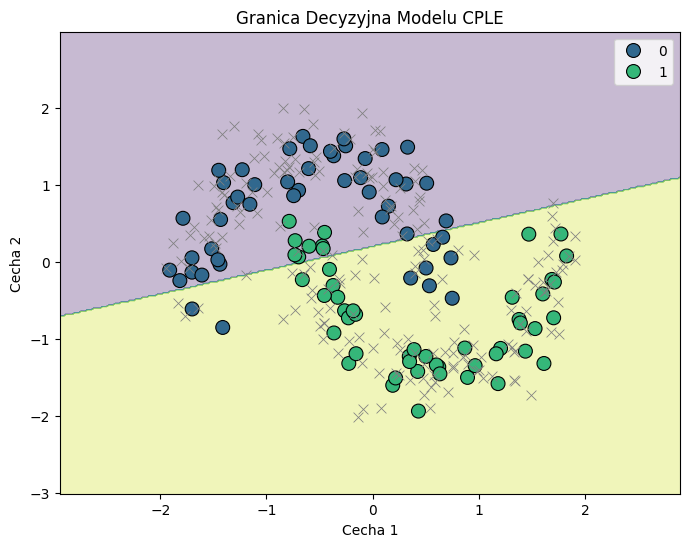

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                       np.arange(y_min, y_max, 0.02))

Z = lr_cple.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap=plt.cm.viridis, alpha=0.3)
sns.scatterplot(x=X_labeled[:, 0], y=X_labeled[:, 1], hue=Y_labeled, palette='viridis', marker='o', s=100, edgecolor='k')
sns.scatterplot(x=X_unlabeled[:, 0], y=X_unlabeled[:, 1], color='gray', marker='x', s=50)
plt.title('Granica Decyzyjna Modelu CPLE')
plt.xlabel('Cecha 1')
plt.ylabel('Cecha 2')
plt.show()